# Aula 16 — Histograma, dispersão e box plot

**Módulo 5 — Visualização de Dados**

## Objetivos da aula

- Analisar a distribuição de uma variável com histogramas.
- Explorar a relação entre duas variáveis com gráficos de dispersão.
- Identificar possíveis valores extremos (*outliers*) com *box plots*.

---

## 1. Recriando a base de dados

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500
tipos_equipamento = ["Motor", "Bomba", "Compressor", "Ventilador"]

df = pd.DataFrame({
    "equipamento_id": [f"EQ-{i:04d}" for i in range(1, n + 1)],
    "tipo_equipamento": np.random.choice(tipos_equipamento, size=n),
    "temperatura": np.round(np.random.normal(70, 12, size=n), 1),
    "pressao": np.round(np.random.normal(5.5, 1.3, size=n), 2),
    "vibracao": np.round(np.random.normal(2.4, 1.1, size=n), 2),
    "horas_operacao": np.random.randint(0, 10000, size=n),
})


def definir_status(linha):
    critico = (linha["temperatura"] >= 90) or (linha["vibracao"] >= 4.5) or (linha["pressao"] >= 8) or (linha["pressao"] <= 2)
    alerta = (linha["temperatura"] >= 80) or (linha["vibracao"] >= 3.5) or (linha["pressao"] >= 7) or (linha["pressao"] <= 3)
    if critico:
        return "critico"
    elif alerta:
        return "alerta"
    else:
        return "normal"


df["status"] = df.apply(definir_status, axis=1)

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline


## 2. Histograma: como os valores estão distribuídos

Um **histograma** divide os valores de uma variável numérica em faixas (*bins*) e conta quantas observações caem em cada faixa. Ele responde à pergunta: "a maioria das leituras está concentrada em qual faixa de valores? A distribuição é simétrica? Existem valores muito distantes do centro?"

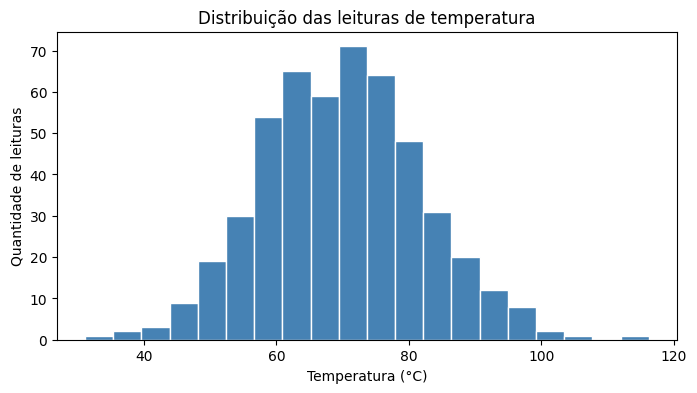

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(df["temperatura"], bins=20, color="steelblue", edgecolor="white")
plt.title("Distribuição das leituras de temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Quantidade de leituras")
plt.show()


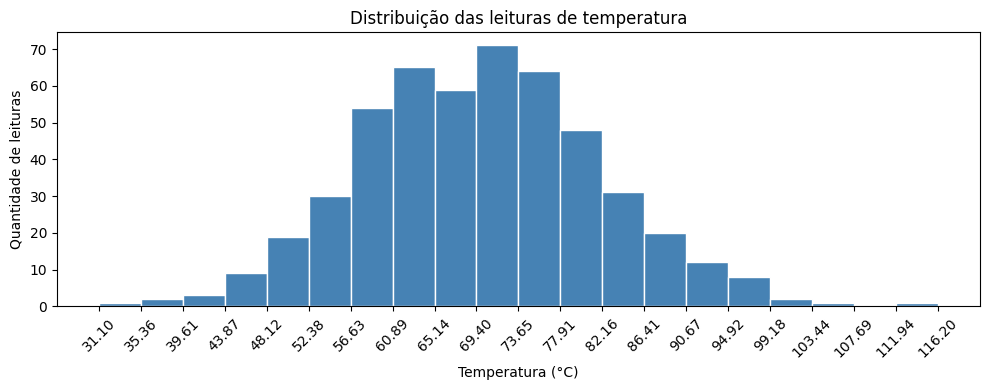

In [9]:
plt.figure(figsize=(10, 4))

frequencias, bins, _ = plt.hist(
    df["temperatura"],
    bins=20,
    color="steelblue",
    edgecolor="white"
)

plt.xticks(bins, rotation=45)

plt.title("Distribuição das leituras de temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Quantidade de leituras")

plt.tight_layout()
plt.show()

Como geramos a temperatura a partir de uma distribuição normal (`np.random.normal`, na Aula 11), o histograma deve mostrar o formato característico de "sino", concentrado ao redor da média — esse é o comportamento esperado de muitas variáveis físicas contínuas, como temperatura e pressão.

### Comparando distribuições com `bins` e transparência

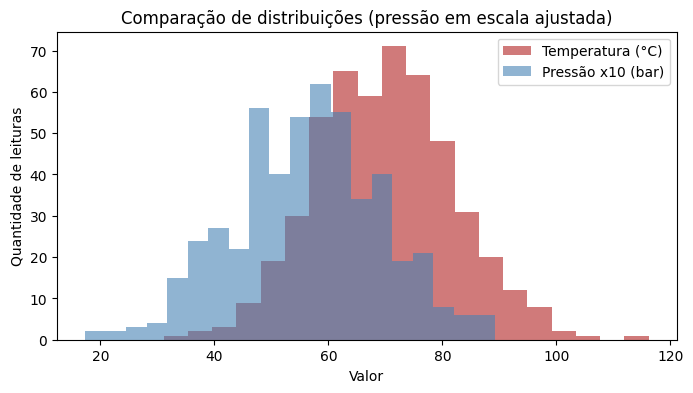

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(df["temperatura"], bins=20, alpha=0.6, label="Temperatura (°C)", color="firebrick")
plt.hist(df["pressao"] * 10, bins=20, alpha=0.6, label="Pressão x10 (bar)", color="steelblue")
plt.title("Comparação de distribuições (pressão em escala ajustada)")
plt.xlabel("Valor")
plt.ylabel("Quantidade de leituras")
plt.legend()
plt.show()


## 3. Gráfico de dispersão (*scatter plot*): relação entre duas variáveis

Um **scatter plot** posiciona cada observação em um plano, cruzando duas variáveis numéricas — ideal para investigar se existe alguma relação entre elas, por exemplo entre temperatura e vibração.

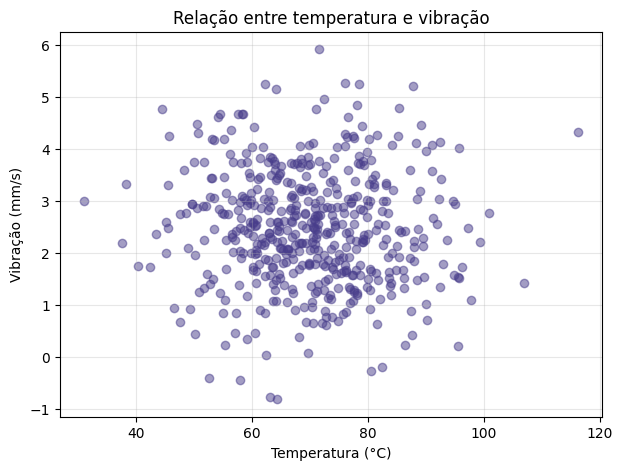

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(df["temperatura"], df["vibracao"], alpha=0.5, color="darkslateblue")
plt.title("Relação entre temperatura e vibração")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Vibração (mm/s)")
plt.grid(True, alpha=0.3)
plt.show()


### Colorindo os pontos por categoria

Quando queremos ver **como uma terceira variável (categórica) se relaciona** com as outras duas, colorimos os pontos de acordo com essa categoria — por exemplo, o `status` do equipamento.

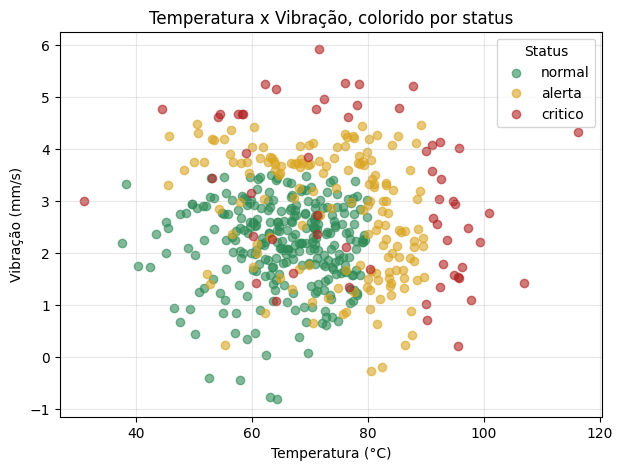

In [6]:
cores_status = {"normal": "seagreen", "alerta": "goldenrod", "critico": "firebrick"}

plt.figure(figsize=(7, 5))
for status, cor in cores_status.items():
    subconjunto = df[df["status"] == status]
    plt.scatter(subconjunto["temperatura"], subconjunto["vibracao"], alpha=0.6, color=cor, label=status)

plt.title("Temperatura x Vibração, colorido por status")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Vibração (mm/s)")
plt.legend(title="Status")
plt.grid(True, alpha=0.3)
plt.show()


Repare como os pontos vermelhos (`critico`) tendem a se concentrar nas regiões de temperatura e/ou vibração mais altas — esse é exatamente o tipo de padrão visual que, no Módulo 6, vamos ensinar um modelo de Machine Learning a reconhecer automaticamente.

## 4. Box plot: resumindo a distribuição e destacando *outliers*

O **box plot** (ou "diagrama de caixa") mostra, em um único desenho compacto:

- a **mediana** (linha dentro da caixa);
- o intervalo entre o 1º e o 3º quartil (a própria caixa, contendo 50% dos dados centrais);
- os "bigodes", que se estendem até o alcance considerado "normal" dos dados;
- pontos individuais além dos bigodes, marcados como possíveis **outliers**.

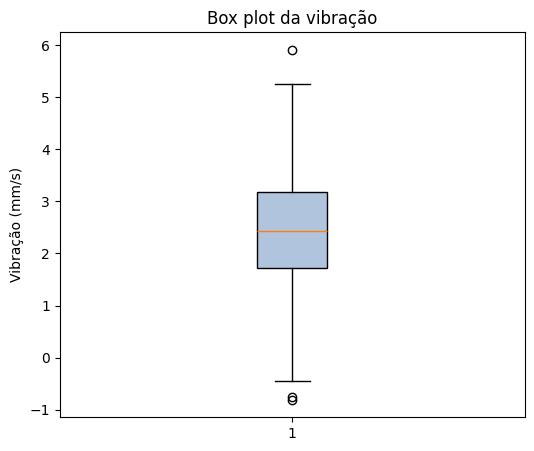

In [7]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["vibracao"], vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightsteelblue"))
plt.title("Box plot da vibração")
plt.ylabel("Vibração (mm/s)")
plt.show()


### Comparando a distribuição entre grupos com box plots lado a lado

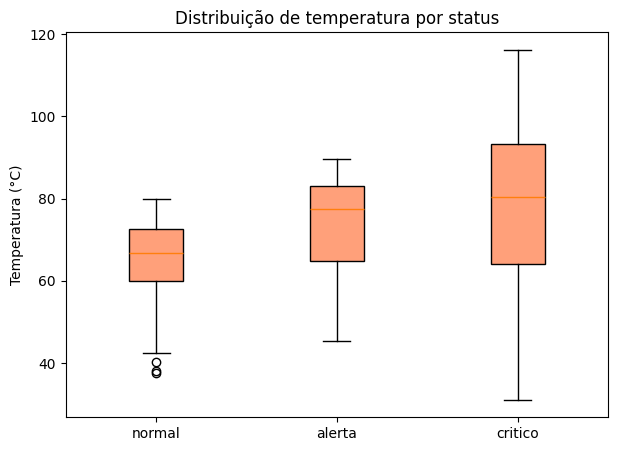

In [8]:
dados_por_status = [df[df["status"] == status]["temperatura"] for status in ["normal", "alerta", "critico"]]

plt.figure(figsize=(7, 5))
plt.boxplot(dados_por_status, labels=["normal", "alerta", "critico"], patch_artist=True,
            boxprops=dict(facecolor="lightsalmon"))
plt.title("Distribuição de temperatura por status")
plt.ylabel("Temperatura (°C)")
plt.show()


## 5. Quando usar cada gráfico

| Gráfico | Pergunta que responde |
|---|---|
| Histograma | Como uma variável está distribuída? Há concentração, assimetria? |
| Dispersão (*scatter*) | Existe relação entre duas variáveis? Os grupos se separam visualmente? |
| Box plot | Qual a mediana e a dispersão dos dados? Há valores extremos (*outliers*)? |

## 6. Resumo da aula

- `plt.hist()` mostra a distribuição de uma variável numérica.
- `plt.scatter()` revela relações entre duas variáveis, e pode ser colorido por uma terceira (categórica).
- `plt.boxplot()` resume mediana, dispersão e outliers, e pode comparar vários grupos lado a lado.
- Esses três gráficos formam o "kit básico" de exploração visual antes de qualquer modelagem — inclusive a que faremos no Módulo 6.

### Exercício sugerido

Crie um histograma da coluna `horas_operacao` e um box plot de `pressao` separado por `tipo_equipamento`. Existe algum tipo de equipamento com mais outliers de pressão que os demais?
